# Лаб 1 СИИ

**Задание:**

Линейная и логистическая регрессия.<br>
Реализовать с нуля алгоритмы используя ООП.<br>
Обучить на датасете ___ <br>
Вывести графики обучения и объяснить их.

из графиков хочу увидеть:
1. падение ошибок
2. рост метрик (f1/accuracy)

из библиотек:
numpy, pandas, polars, pytorch <br>
мы не используем вложенные методы торча <br>
Реализуем с нуля (умножением матриц numpy/тензоров torch)

для графиков юзаем seaborn/matplotlib

за торч получаем плюсики

датасеты:
классификация титаника и
регрессия дома в калифорнии

буду счастлив видеть обработку датасета, но если ее не будет, надо будет объяснить как делалась

# Датасет Titanic

In [ ]:
import pandas as pd

titanic = pd.read_csv('Titanic-Dataset.csv')
print(titanic)

titanic.Sex = titanic.Sex.map({'female':0, 'male':1})
titanic.Embarked = titanic.Embarked.map({'S':0, 'C':1, 'Q':2,'nan':'NaN'})

titanic

# графики
# intercept
# predict_proba

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,1
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,NaN,0
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,NaN,1,2,W./C. 6607,23.4500,NaN,0
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,1


In [ ]:
titanic = titanic.drop(['Name','Ticket','Cabin','PassengerId'], axis=1)
titanic.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [ ]:
mean_age_men=titanic[titanic['Sex']==1]['Age'].mean()
mean_age_women=titanic[titanic['Sex']==0]['Age'].mean()

titanic.loc[(titanic.Age.isnull()) & (titanic['Sex']==0),'Age']=mean_age_women
titanic.loc[(titanic.Age.isnull()) & (titanic['Sex']==1),'Age']=mean_age_men

titanic.dropna(inplace=True)

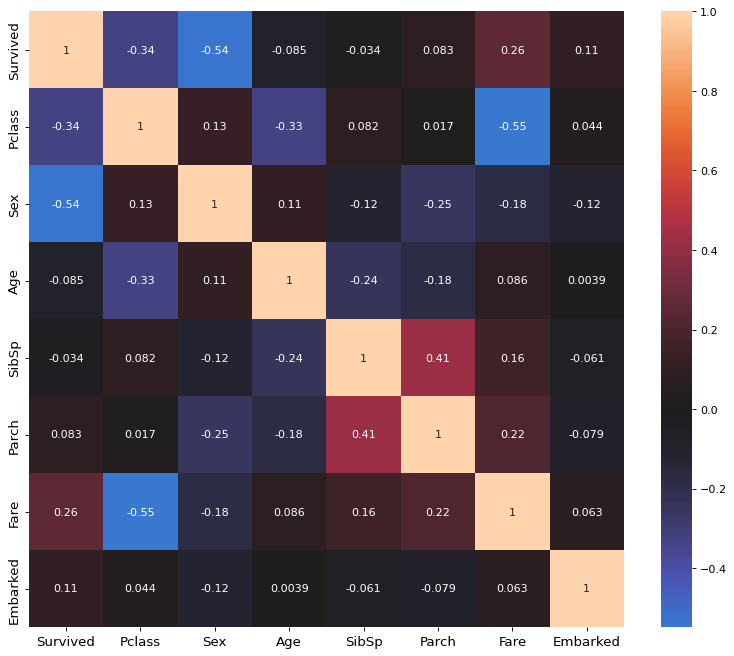

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.000000,1,0,7.2500,0
1,1,1,0,38.000000,1,0,71.2833,1
2,1,3,0,26.000000,0,0,7.9250,0
3,1,1,0,35.000000,1,0,53.1000,0
4,0,3,1,35.000000,0,0,8.0500,0
...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,0
887,1,1,0,19.000000,0,0,30.0000,0
888,0,3,0,27.915709,1,2,23.4500,0
889,1,1,1,26.000000,0,0,30.0000,1


In [ ]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10), dpi= 80)
sns.heatmap(titanic.corr(), xticklabels=titanic.corr().columns, yticklabels=titanic.corr().columns, center=0, annot=True,)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

titanic

In [ ]:
import numpy as np
from dataclasses import dataclass

@dataclass
class SeparateData:
  X_train: np.ndarray
  y_train: np.ndarray
  X_val: np.ndarray
  y_val: np.ndarray
  X_test: np.ndarray
  y_test: np.ndarray

class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X: np.ndarray) -> None:
        X = np.asarray(X, dtype=np.float64)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)

        self.std[self.std == 0] = 1.0

    def transform(self, X: np.ndarray) -> np.ndarray:
        if self.mean is None or self.std is None:
            return X

        X = np.asarray(X, dtype=np.float64)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        return (X - self.mean) / self.std

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        self.fit(X)
        return self.transform(X)

class DataSeparator:
   def __init__(self, val_size: float = 0.2, test_size: float = 0.1,
                 shuffle: bool = True, seed: int = 42):
        self.val_size = val_size
        self.test_size = test_size
        self.shuffle = shuffle
        self.seed = seed
   def separate(self, X: np.ndarray, y: np.ndarray) -> SeparateData:
    n_samples = X.shape[0]
    indices = np.arange(n_samples)

    if self.shuffle:
         np.random.seed(self.seed)
         np.random.shuffle(indices)

    test_samples = int(n_samples * self.test_size)
    val_samples = int(n_samples * self.val_size)
    train_samples = n_samples - test_samples - val_samples

    train_indices = indices[:train_samples]
    val_indices = indices[train_samples: train_samples + val_samples]
    test_indices = indices[train_samples + val_samples:]

    X_train, y_train = X[train_indices], y[train_indices]
    X_val, y_val = X[val_indices], y[val_indices]
    X_test, y_test = X[test_indices], y[test_indices]

    return SeparateData(X_train, y_train, X_val, y_val, X_test, y_test)

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

@dataclass
class TrainingHistoryLogistic:
    losses: list[float]
    accuracies: list[float]
    f1_scores: list[float]
    val_losses: list[float]
    val_accuracies: list[float]
    val_f1_scores: list[float]


class LogisticRegression:
  def __init__(self, learning_rate: float = 0.01, n_iterations: int = 1000,
                 tolerance: float = 1e-6, fit_intercept: bool = True, verbose: bool = False):
    self.learning_rate = learning_rate
    self.n_iterations = n_iterations
    self.tolerance = tolerance
    self.fit_intercept = fit_intercept
    self.verbose = verbose
    self.weights = None
    self.bias = 0.0 if fit_intercept else None
    self.is_fitted = False
    self.history = None

  @staticmethod
  def sigmoid(z: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-z))

  def compute_loss(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

  def gradient_descent(self, X: np.ndarray, y: np.ndarray, X_val: np.ndarray = None, y_val: np.ndarray = None):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        if self.fit_intercept:
            self.bias = 0.0

        losses, accuracies, f1_scores = [], [], []
        val_losses, val_accuracies, val_f1_scores = [], [], []

        for iteration in range(self.n_iterations):
            linear_model = np.dot(X, self.weights)
            if self.fit_intercept:
                linear_model += self.bias
            y_pred_prob = self.sigmoid(linear_model)
            y_pred = (y_pred_prob >= 0.5).astype(int)

            loss = self.compute_loss(y, y_pred_prob)
            acc = accuracy_score(y, y_pred)
            f1 = f1_score(y, y_pred)

            losses.append(loss)
            accuracies.append(acc)
            f1_scores.append(f1)

           # Validation metrics
            if X_val is not None and y_val is not None:
                val_prob = self.sigmoid(np.dot(X_val, self.weights) + (self.bias if self.fit_intercept else 0))
                val_pred = (val_prob >= 0.5).astype(int)
                val_loss = self.compute_loss(y_val, val_prob)
                val_acc = accuracy_score(y_val, val_pred)
                val_f1 = f1_score(y_val, val_pred)

                val_losses.append(val_loss)
                val_accuracies.append(val_acc)
                val_f1_scores.append(val_f1)

             # Gradients
            error = y_pred_prob - y
            dw = (1 / n_samples) * np.dot(X.T, error)
            self.weights -= self.learning_rate * dw
            if self.fit_intercept:
                db = (1 / n_samples) * np.sum(error)
                self.bias -= self.learning_rate * db

            if iteration > 0 and abs(losses[-2] - losses[-1]) < self.tolerance:
                if self.verbose:
                    print(f"Converged at iteration {iteration}")
                break

            if self.verbose and iteration % 100 == 0:
                msg = f"Iteration {iteration}, Train Loss: {loss:.6f}, Acc: {acc:.3f}, F1: {f1:.3f}"
                if X_val is not None:
                    msg += f", Val Loss: {val_loss:.6f}, Val Acc: {val_acc:.3f}, Val F1: {val_f1:.3f}"
                print(msg)

        self.history = TrainingHistoryLogistic(
            losses=losses,
            accuracies=accuracies,
            f1_scores=f1_scores,
            val_losses=val_losses,
            val_accuracies=val_accuracies,
            val_f1_scores=val_f1_scores
        )

  def fit(self, X: np.ndarray, y: np.ndarray, X_val: np.ndarray = None, y_val: np.ndarray = None):
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        if X_val is not None and X_val.ndim == 1:
            X_val = X_val.reshape(-1, 1)

        self.gradient_descent(X, y, X_val, y_val)
        self.is_fitted = True

  def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if not self.is_fitted:
            raise ValueError("Model is not fitted yet!")

        if X.ndim == 1:
            X = X.reshape(-1, 1)
        linear_model = np.dot(X, self.weights)
        if self.fit_intercept:
            linear_model += self.bias
        return self.sigmoid(linear_model)

  def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

  def score(self, X: np.ndarray, y: np.ndarray) -> float:
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

  def plot_metrics(self):
        fig, axes = plt.subplots(1, 3, figsize=(18,5))

        # Loss
        axes[0].plot(self.history.losses, label='Train')
        if self.history.val_losses:
            axes[0].plot(self.history.val_losses, label='Validation')
        axes[0].set_title("Loss")
        axes[0].legend()
        axes[0].grid(True)

        # Accuracy
        axes[1].plot(self.history.accuracies, label='Train')
        if self.history.val_accuracies:
            axes[1].plot(self.history.val_accuracies, label='Validation')
        axes[1].set_title("Accuracy")
        axes[1].legend()
        axes[1].grid(True)

        # F1 Score
        axes[2].plot(self.history.f1_scores, label='Train')
        if self.history.val_f1_scores:
            axes[2].plot(self.history.val_f1_scores, label='Validation')
        axes[2].set_title("F1 Score")
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()



Iteration 0, Train Loss: 0.693147, Acc: 0.393, F1: 0.565, Val Loss: 0.693147, Val Acc: 0.383, Val F1: 0.554
Iteration 100, Train Loss: 0.445785, Acc: 0.799, F1: 0.737, Val Loss: 0.464029, Val Acc: 0.774, Val F1: 0.694
Iteration 200, Train Loss: 0.434749, Acc: 0.799, F1: 0.738, Val Loss: 0.451688, Val Acc: 0.782, Val F1: 0.701
Iteration 300, Train Loss: 0.432535, Acc: 0.806, F1: 0.747, Val Loss: 0.449109, Val Acc: 0.789, Val F1: 0.708
Iteration 400, Train Loss: 0.431863, Acc: 0.801, F1: 0.743, Val Loss: 0.448570, Val Acc: 0.797, Val F1: 0.716
Iteration 500, Train Loss: 0.431621, Acc: 0.803, F1: 0.745, Val Loss: 0.448611, Val Acc: 0.797, Val F1: 0.716
Converged at iteration 539


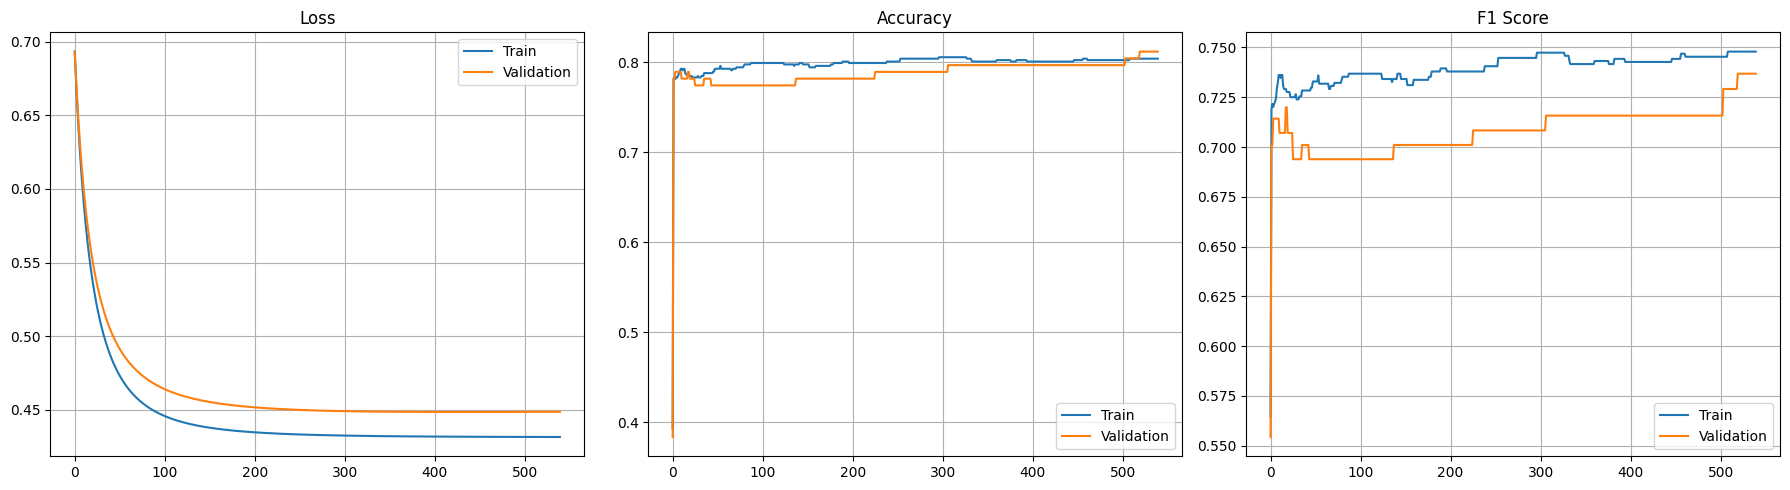

Размеры выборок:
Train: 623 samples
Validation: 133 samples
Test: 133 samples
Features: 7 features
Accuracy на тестовой выборке: 0.7518796992481203
F1 на тестовой выборке: 0.6373626373626373
Accuracy на обучающей выборке: 0.8041733547351525
F1 на обучающей выборке: 0.7479338842975206


In [ ]:
target_column = 'Survived'
X_cleaned = titanic.drop(target_column, axis=1).values
y_cleaned = titanic[target_column].values

separator = DataSeparator(test_size=0.15, val_size=0.15, shuffle=True, seed=42)
data_splits = separator.separate(X_cleaned, y_cleaned)

scaler = StandardScaler()
scaler.fit(data_splits.X_train)

data_splits.X_train = scaler.transform(data_splits.X_train)
data_splits.X_val = scaler.transform(data_splits.X_val)
data_splits.X_test = scaler.transform(data_splits.X_test)

model = LogisticRegression(learning_rate=0.1, n_iterations=10000, verbose=True)

model.fit(data_splits.X_train, data_splits.y_train, data_splits.X_val, data_splits.y_val)

predictions = model.predict(data_splits.X_test)

model.plot_metrics()

print("Размеры выборок:")
print(f"Train: {data_splits.X_train.shape[0]} samples")
print(f"Validation: {data_splits.X_val.shape[0]} samples")
print(f"Test: {data_splits.X_test.shape[0]} samples")
print(f"Features: {data_splits.X_train.shape[1]} features")
print(f"Accuracy на тестовой выборке: {model.score(data_splits.X_test, data_splits.y_test)}")
print(f"F1 на тестовой выборке: {f1_score(data_splits.y_test, predictions)}")
print(f"Accuracy на обучающей выборке: {model.score(data_splits.X_train, data_splits.y_train)}")
print(f"F1 на обучающей выборке: {f1_score(data_splits.y_train, model.predict(data_splits.X_train))}")

# Датасет Калифорникейшн

In [ ]:
import pandas as pd

californication = pd.read_csv('California_Houses.csv')
californication

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
0,452600.0,8.3252,41,880,129,322,126,37.88,-122.23,9263.040773,556529.158342,735501.806984,67432.517001,21250.213767
1,358500.0,8.3014,21,7099,1106,2401,1138,37.86,-122.22,10225.733072,554279.850069,733236.884360,65049.908574,20880.600400
2,352100.0,7.2574,52,1467,190,496,177,37.85,-122.24,8259.085109,554610.717069,733525.682937,64867.289833,18811.487450
3,341300.0,5.6431,52,1274,235,558,219,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
4,342200.0,3.8462,52,1627,280,565,259,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,78100.0,1.5603,25,1665,374,845,330,39.48,-121.09,162031.481121,654530.186299,830631.543047,248510.058162,222619.890417
20636,77100.0,2.5568,18,697,150,356,114,39.49,-121.21,160445.433537,659747.068444,836245.915229,246849.888948,218314.424634
20637,92300.0,1.7000,17,2254,485,1007,433,39.43,-121.22,153754.341182,654042.214020,830699.573163,240172.220489,212097.936232
20638,84700.0,1.8672,18,1860,409,741,349,39.43,-121.32,152005.022239,657698.007703,834672.461887,238193.865909,207923.199166


In [ ]:
californication.isnull().sum()

,0
Median_House_Value,0
Median_Income,0
Median_Age,0
Tot_Rooms,0
Tot_Bedrooms,0
Population,0
Households,0
Latitude,0
Longitude,0
Distance_to_coast,0


In [ ]:
californication.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Median_House_Value        20640 non-null  float64
 1   Median_Income             20640 non-null  float64
 2   Median_Age                20640 non-null  int64  
 3   Tot_Rooms                 20640 non-null  int64  
 4   Tot_Bedrooms              20640 non-null  int64  
 5   Population                20640 non-null  int64  
 6   Households                20640 non-null  int64  
 7   Latitude                  20640 non-null  float64
 8   Longitude                 20640 non-null  float64
 9   Distance_to_coast         20640 non-null  float64
 10  Distance_to_LA            20640 non-null  float64
 11  Distance_to_SanDiego      20640 non-null  float64
 12  Distance_to_SanJose       20640 non-null  float64
 13  Distance_to_SanFrancisco  20640 non-null  float64
dtypes: flo

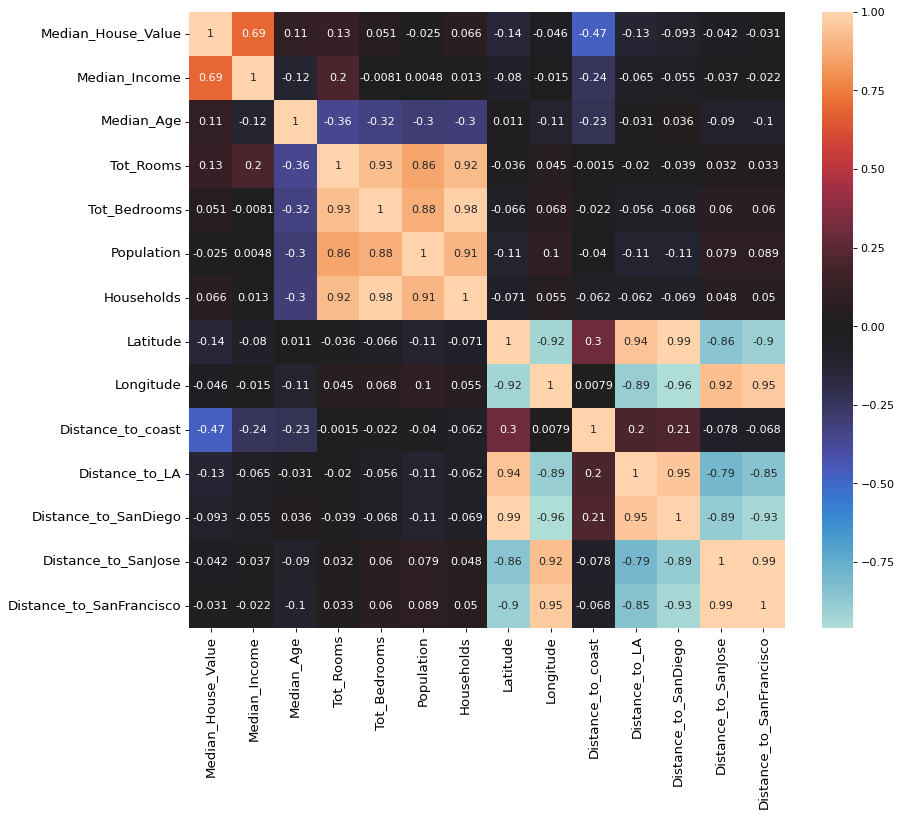

In [ ]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10), dpi= 80)
sns.heatmap(californication.corr(), xticklabels=californication.corr().columns, yticklabels=californication.corr().columns, center=0, annot=True,)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [ ]:
californication = californication.drop(['Tot_Bedrooms', 'Population', 'Households', 'Distance_to_SanDiego',
                                        'Distance_to_SanFrancisco', 'Distance_to_SanJose', 'Longtitude'], axis=1)

californication

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Latitude,Distance_to_coast,Distance_to_LA
0,452600.0,8.3252,41,880,37.88,9263.040773,556529.158342
1,358500.0,8.3014,21,7099,37.86,10225.733072,554279.850069
2,352100.0,7.2574,52,1467,37.85,8259.085109,554610.717069
3,341300.0,5.6431,52,1274,37.85,7768.086571,555194.266086
4,342200.0,3.8462,52,1627,37.85,7768.086571,555194.266086
...,...,...,...,...,...,...,...
20635,78100.0,1.5603,25,1665,39.48,162031.481121,654530.186299
20636,77100.0,2.5568,18,697,39.49,160445.433537,659747.068444
20637,92300.0,1.7000,17,2254,39.43,153754.341182,654042.214020
20638,84700.0,1.8672,18,1860,39.43,152005.022239,657698.007703


In [ ]:
@dataclass
class TrainingHistory:
    losses: list[float]
    train_loss_history: list[float]
    val_loss_history: list[float]
    train_mae_history: list[float]
    val_mae_history: list[float]
    train_rmse_history: list[float]
    val_rmse_history: list[float]

class LinearRegression:
    def __init__(self, learning_rate: float = 0.01, n_iterations: int = 10000,
                 tolerance: float = 1e-6, fit_intercept: bool = True, verbose: bool = False):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.tolerance = tolerance
        self.fit_intercept = fit_intercept
        self.verbose = verbose

        self.weights = None
        self.bias = 0.0 if fit_intercept else None
        self.is_fitted = False
        self.history = None

    def compute_loss(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        return np.mean((y_true - y_pred) ** 2)

    def compute_mae(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        return np.mean(np.abs(y_true - y_pred))

    def compute_rmse(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        return np.sqrt(self.compute_loss(y_true, y_pred))

    def gradient_descent(self, X: np.ndarray, y: np.ndarray, X_val: np.ndarray = None, y_val: np.ndarray = None):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        if self.fit_intercept:
            self.bias = 0.0

        losses = []
        train_loss_history = []
        val_loss_history = []
        train_mae_history = []
        val_mae_history = []
        train_rmse_history = []
        val_rmse_history = []

        for iteration in range(self.n_iterations):
            y_pred = np.dot(X, self.weights)
            if self.fit_intercept:
                y_pred += self.bias

            train_loss = self.compute_loss(y, y_pred)
            train_mae = self.compute_mae(y, y_pred)
            train_rmse = self.compute_rmse(y, y_pred)

            train_loss_history.append(train_loss)
            train_mae_history.append(train_mae)
            train_rmse_history.append(train_rmse)
            losses.append(train_loss)

            val_loss = val_mae = val_rmse = None
            if X_val is not None and y_val is not None:
                y_val_pred = np.dot(X_val, self.weights)
                if self.fit_intercept:
                    y_val_pred += self.bias

                val_loss = self.compute_loss(y_val, y_val_pred)
                val_mae = self.compute_mae(y_val, y_val_pred)
                val_rmse = self.compute_rmse(y_val, y_val_pred)

                val_loss_history.append(val_loss)
                val_mae_history.append(val_mae)
                val_rmse_history.append(val_rmse)

            error = y_pred - y
            dw = (2 / n_samples) * np.dot(X.T, error)

            self.weights -= self.learning_rate * dw

            if self.fit_intercept:
                db = (2 / n_samples) * np.sum(error)
                self.bias -= self.learning_rate * db

            if iteration > 0 and abs(losses[-2] - losses[-1]) < self.tolerance:
                if self.verbose:
                    print(f"Converged at iteration {iteration}")
                break

            if self.verbose and iteration % 100 == 0:
                msg = f"Iteration {iteration}, Train Loss: {train_loss:.6f}"
                if val_loss is not None and val_mae is not None and val_rmse is not None:
                    msg += f", Val Loss: {val_loss:.6f}, MAE: {val_mae:.6f}, RMSE: {val_rmse:.6f}"
                print(msg)

        self.history = TrainingHistory(
            losses=losses,
            train_loss_history=train_loss_history,
            val_loss_history=val_loss_history,
            train_mae_history=train_mae_history,
            val_mae_history=val_mae_history,
            train_rmse_history=train_rmse_history,
            val_rmse_history=val_rmse_history
        )

    def fit(self, X: np.ndarray, y: np.ndarray, X_val: np.ndarray = None, y_val: np.ndarray = None):
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        if X_val is not None and X_val.ndim == 1:
            X_val = X_val.reshape(-1, 1)

        self.gradient_descent(X, y, X_val, y_val)
        self.is_fitted = True

        if self.verbose:
            final_loss = self.compute_loss(y, self.predict(X))
            final_mae = self.compute_mae(y, self.predict(X))
            final_rmse = self.compute_rmse(y, self.predict(X))
            print(f"Training completed. Final loss: {final_loss:.6f}, final MAE: {final_mae:.6f}, final RMSE: {final_rmse:.6f}")

    def predict(self, X: np.ndarray) -> np.ndarray:
        if not self.is_fitted:
            return X

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        y_pred = np.dot(X, self.weights)
        if self.fit_intercept:
            y_pred += self.bias

        return y_pred

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)

    def plot_metrics(self):
      fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # MSE
      axes[0].plot(self.history.train_loss_history, label='Train')
      if self.history.val_loss_history:
          axes[0].plot(self.history.val_loss_history, label='Validation')
      axes[0].set_title('MSE during Training')
      axes[0].set_yscale('log')
      axes[0].legend()
      axes[0].grid(True)

    # MAE
      axes[1].plot(self.history.train_mae_history, label='Train')
      if self.history.val_mae_history:
          axes[1].plot(self.history.val_mae_history, label='Validation')
      axes[1].set_title('MAE during Training')
      axes[1].set_yscale('log')
      axes[1].legend()
      axes[1].grid(True)

    # RMSE
      axes[2].plot(self.history.train_rmse_history, label='Train')
      if self.history.val_rmse_history:
          axes[2].plot(self.history.val_rmse_history, label='Validation')
      axes[2].set_title('RMSE during Training')
      axes[2].set_yscale('log')
      axes[2].legend()
      axes[2].grid(True)

      plt.tight_layout()
      plt.show()

Iteration 0, Train Loss: 56213568296.005402, Val Loss: 54801321983.245804, MAE: 204231.629522, RMSE: 234096.821814
Iteration 100, Train Loss: 6364218204.637964, Val Loss: 6165204486.349066, MAE: 55696.750229, RMSE: 78518.816129
Iteration 200, Train Loss: 5525024106.238424, Val Loss: 5371789524.410724, MAE: 54571.161436, RMSE: 73292.492961
Iteration 300, Train Loss: 5501580173.073003, Val Loss: 5351748027.594728, MAE: 54831.050474, RMSE: 73155.642486
Iteration 400, Train Loss: 5495296794.593843, Val Loss: 5346193749.702589, MAE: 54845.684910, RMSE: 73117.670571
Iteration 500, Train Loss: 5490506415.664699, Val Loss: 5342253033.946605, MAE: 54829.169677, RMSE: 73090.717837
Iteration 600, Train Loss: 5486594478.316452, Val Loss: 5339279732.219459, MAE: 54814.460723, RMSE: 73070.375202
Iteration 700, Train Loss: 5483385409.059610, Val Loss: 5336988063.231600, MAE: 54804.696351, RMSE: 73054.692274
Iteration 800, Train Loss: 5480751717.548977, Val Loss: 5335208932.328551, MAE: 54798.707376, 

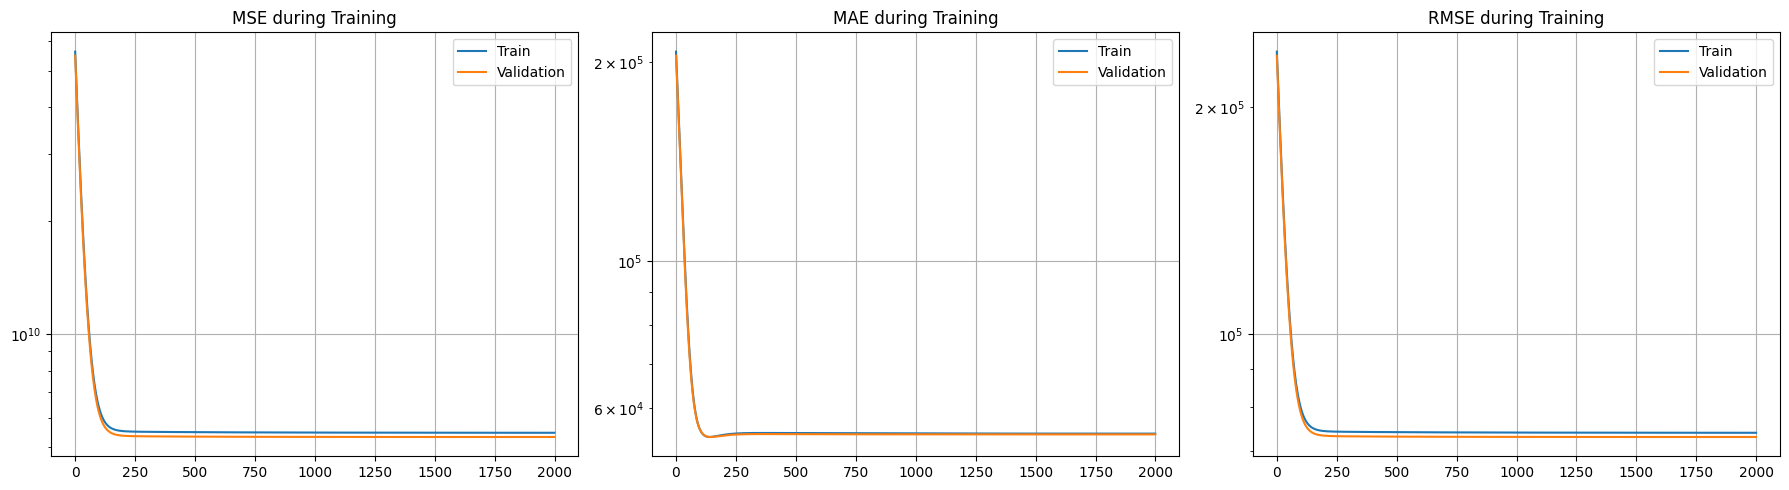


Размеры выборок:
Train: 14448 samples
R^2 на тестовой выборке: 0.5934
R^2 на обучающие выборке: 0.5885
Validation: 3096 samples
Test: 3096 samples
Features: 6 features


In [ ]:
if __name__ == "__main__":
    target_column = 'Median_House_Value'
    X_cleaned = californication.drop(target_column, axis=1).values
    y_cleaned = californication[target_column].values

    separator = DataSeparator(test_size=0.15, val_size=0.15, shuffle=True, seed=42)
    data_splits = separator.separate(X_cleaned, y_cleaned)

    scaler = StandardScaler()
    scaler.fit(data_splits.X_train)

    data_splits.X_train = scaler.transform(data_splits.X_train)
    data_splits.X_val = scaler.transform(data_splits.X_val)
    data_splits.X_test = scaler.transform(data_splits.X_test)

    model = LinearRegression(learning_rate=0.01, n_iterations=2000, verbose = True)

    model.fit(data_splits.X_train, data_splits.y_train, data_splits.X_val, data_splits.y_val)

    predictions = model.predict(data_splits.X_test)

    r2_test = model.score(data_splits.X_test, data_splits.y_test)
    r2_train = model.score(data_splits.X_train, data_splits.y_train)

    model.plot_metrics()

    print("\nРазмеры выборок:")
    print(f"Train: {data_splits.X_train.shape[0]} samples")
    print(f"R^2 на тестовой выборке: {r2_test:.4f}")
    print(f"R^2 на обучающие выборке: {r2_train:.4f}")
    print(f"Validation: {data_splits.X_val.shape[0]} samples")
    print(f"Test: {data_splits.X_test.shape[0]} samples")
    print(f"Features: {data_splits.X_train.shape[1]} features")
